# SVD e PCA per l'Analisi di Immagini Mediche

**Progetto — Statistical Methods**

Questo notebook dimostra come le tecniche di **Singular Value Decomposition (SVD)** e
**Principal Component Analysis (PCA)** possano essere utilizzate per comprimere e analizzare
radiografie polmonari in scala di grigi.

**Dataset:** Lung X-Rays Grayscale — 4 classi:
- Corona Virus Disease
- Normal
- Pneumonia
- Tuberculosis

In [1]:
# === IMPORT DEI MODULI DEL PROGETTO ===
from config import setup_plot_style, CLASSES
from data_loader import (count_images, print_image_counts,
                         load_sample_images, print_sample_properties,
                         load_dataset)
from svd_engine import apply_svd, print_svd_info
from visualization import (plot_exploration, plot_svd_reconstruction,
                           plot_class_comparison)
from src.analysis import (plot_scree, plot_mse_psnr, run_pca, plot_pca_scatter,
                      plot_eigenfaces, print_summary_table)

setup_plot_style()

---
## Fase 1 -- Esplorazione dei Dati
Carichiamo le immagini, verifichiamo che siano matrici 2D in scala di grigi e ne studiamo le
caratteristiche statistiche di base.

In [2]:
# === CONTEGGIO IMMAGINI PER CLASSE ===
counts = count_images()
print_image_counts(counts)

CONTEGGIO IMMAGINI NEL DATASET

--- DATASET ---
  Corona Virus Disease          :  122 immagini
  Normal                        :  540 immagini
  Pneumonia                     :  186 immagini
  Tuberculosis                  :  333 immagini


In [3]:
# === CARICAMENTO E VERIFICA CAMPIONI ===
sample_images = load_sample_images()
print_sample_properties(sample_images)


PROPRIETA' DELLE IMMAGINI CAMPIONE

  Classe: Corona Virus Disease
    Shape:  (230, 203)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  116.07
    Std:    44.54
    2D?     Si [OK]

  Classe: Normal
    Shape:  (1654, 1678)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  124.91
    Std:    57.82
    2D?     Si [OK]

  Classe: Pneumonia
    Shape:  (1216, 1512)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  77.16
    Std:    41.98
    2D?     Si [OK]

  Classe: Tuberculosis
    Shape:  (512, 512)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    193
    Media:  126.62
    Std:    39.60
    2D?     Si [OK]


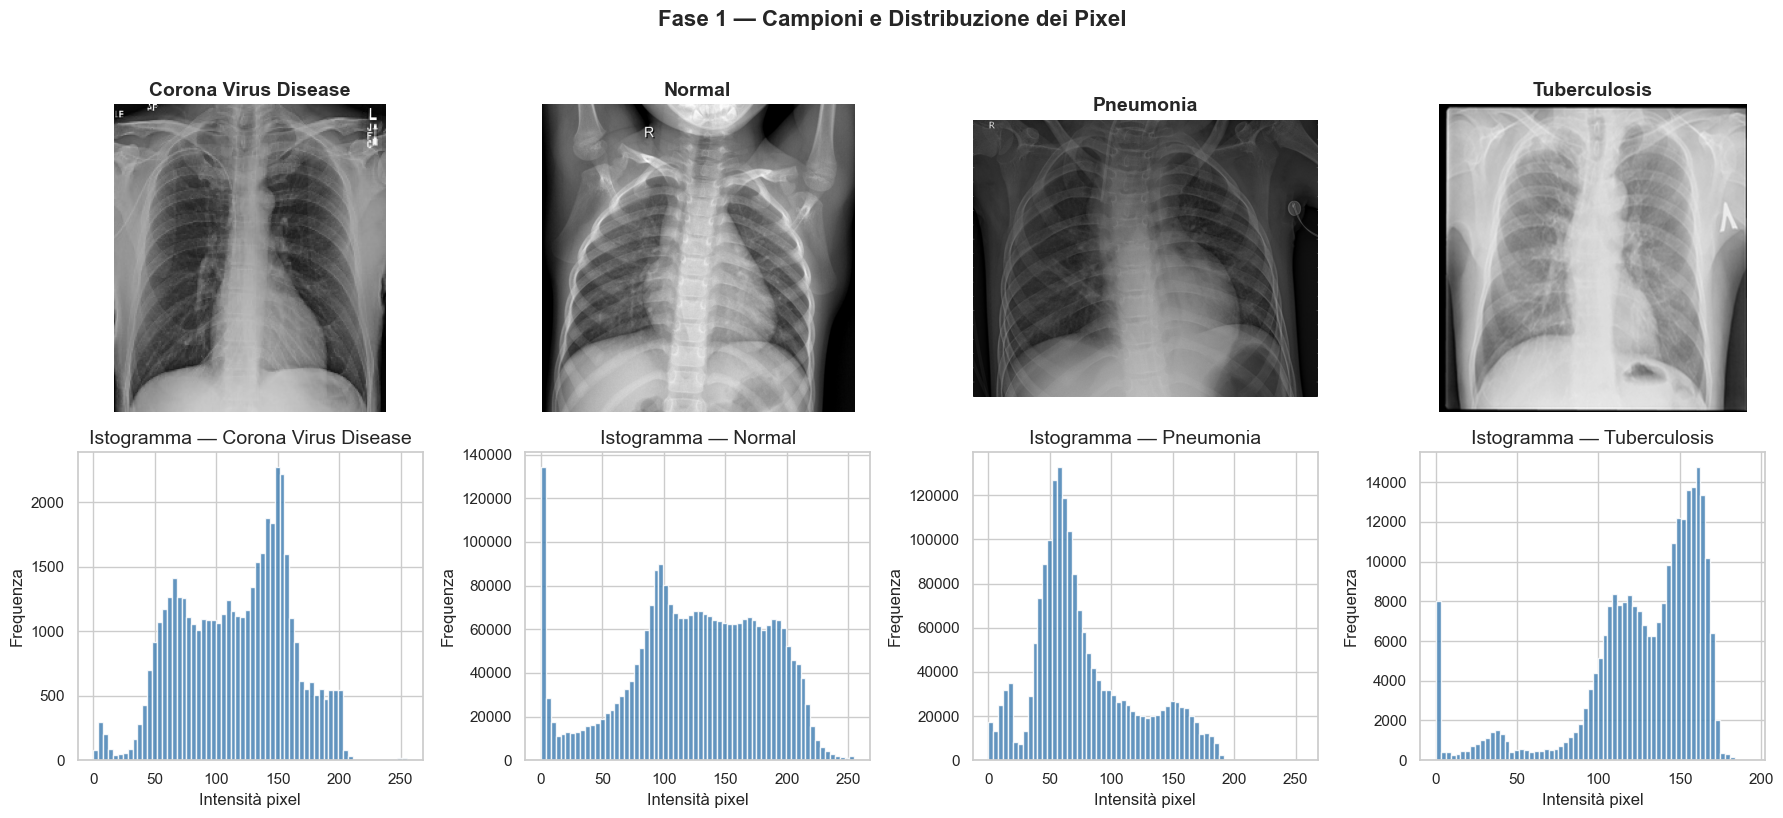

In [4]:
# === VISUALIZZAZIONE CAMPIONI + ISTOGRAMMA DEI PIXEL ===
plot_exploration(sample_images)

---
## Fase 2 -- Pre-elaborazione
Ridimensioniamo tutte le immagini a 256x256 e le normalizziamo in [0, 1].

In [5]:
# === CARICAMENTO BATCH PRE-ELABORATO ===
images_by_class, all_images, labels = load_dataset()

  Caricate  80 immagini per 'Corona Virus Disease'  (scartate 4 con tilt > 10°)
  Caricate  80 immagini per 'Normal'  (scartate 1 con tilt > 10°)
  Caricate  80 immagini per 'Pneumonia'  (scartate 1 con tilt > 10°)
  Caricate  80 immagini per 'Tuberculosis'  (scartate 6 con tilt > 10°)

Dataset totale: (320, 256, 256)  --  320 immagini, 256x256 pixel


---
## Fase 3 -- Il Motore Matematico: SVD

La **Singular Value Decomposition** scompone una matrice $A_{m \times n}$ come:

$$A = U \cdot \Sigma \cdot V^T$$

dove:
- $U$ (m x m): vettori singolari sinistri (strutture delle righe)
- $\Sigma$ (diagonale): valori singolari ordinati $\sigma_1 \geq \sigma_2 \geq \dots \geq 0$
- $V^T$ (n x n): vettori singolari destri (strutture delle colonne)

**Approssimazione di rango k:**

$$A_k = \sum_{i=1}^{k} \sigma_i \, \mathbf{u}_i \, \mathbf{v}_i^T$$

Usando solo le prime $k$ componenti si ottiene la migliore approssimazione di rango $k$
(teorema di Eckart-Young).

In [6]:
# === DEMO SVD SU UNA SINGOLA IMMAGINE ===
demo_img = images_by_class["Normal"][0]
U, S, Vt = apply_svd(demo_img)
print_svd_info(demo_img, U, S, Vt)

Immagine originale:  256 × 256 = 65,536 valori
Valori singolari:    256 = min(m, n)

Matrice U:   (256, 256)
Vettore S:   (256,)
Matrice Vt:  (256, 256)

Primi 10 valori singolari: [133.23  20.15  16.65  12.27  10.28   7.72   6.12   5.18   4.49   4.39]
Ultimi 5 valori singolari: [0.000904 0.000482 0.000251 0.000165 0.      ]


---
## Fase 4 -- Ricostruzione e Visualizzazione
Ricostruiamo l'immagine con diversi valori di $k$ e confrontiamo visivamente la qualita'.

    k    Compressione         MSE   PSNR (dB)
------------------------------------------------
    1          0.78%    0.018516       17.32
    5          3.91%    0.004147       23.82
   10          7.83%    0.001666       27.78
   20         15.66%    0.000579       32.37
   50         39.14%    0.000098       40.09
  100         78.28%    0.000010       50.00
  200        100.00%    0.000000       71.54


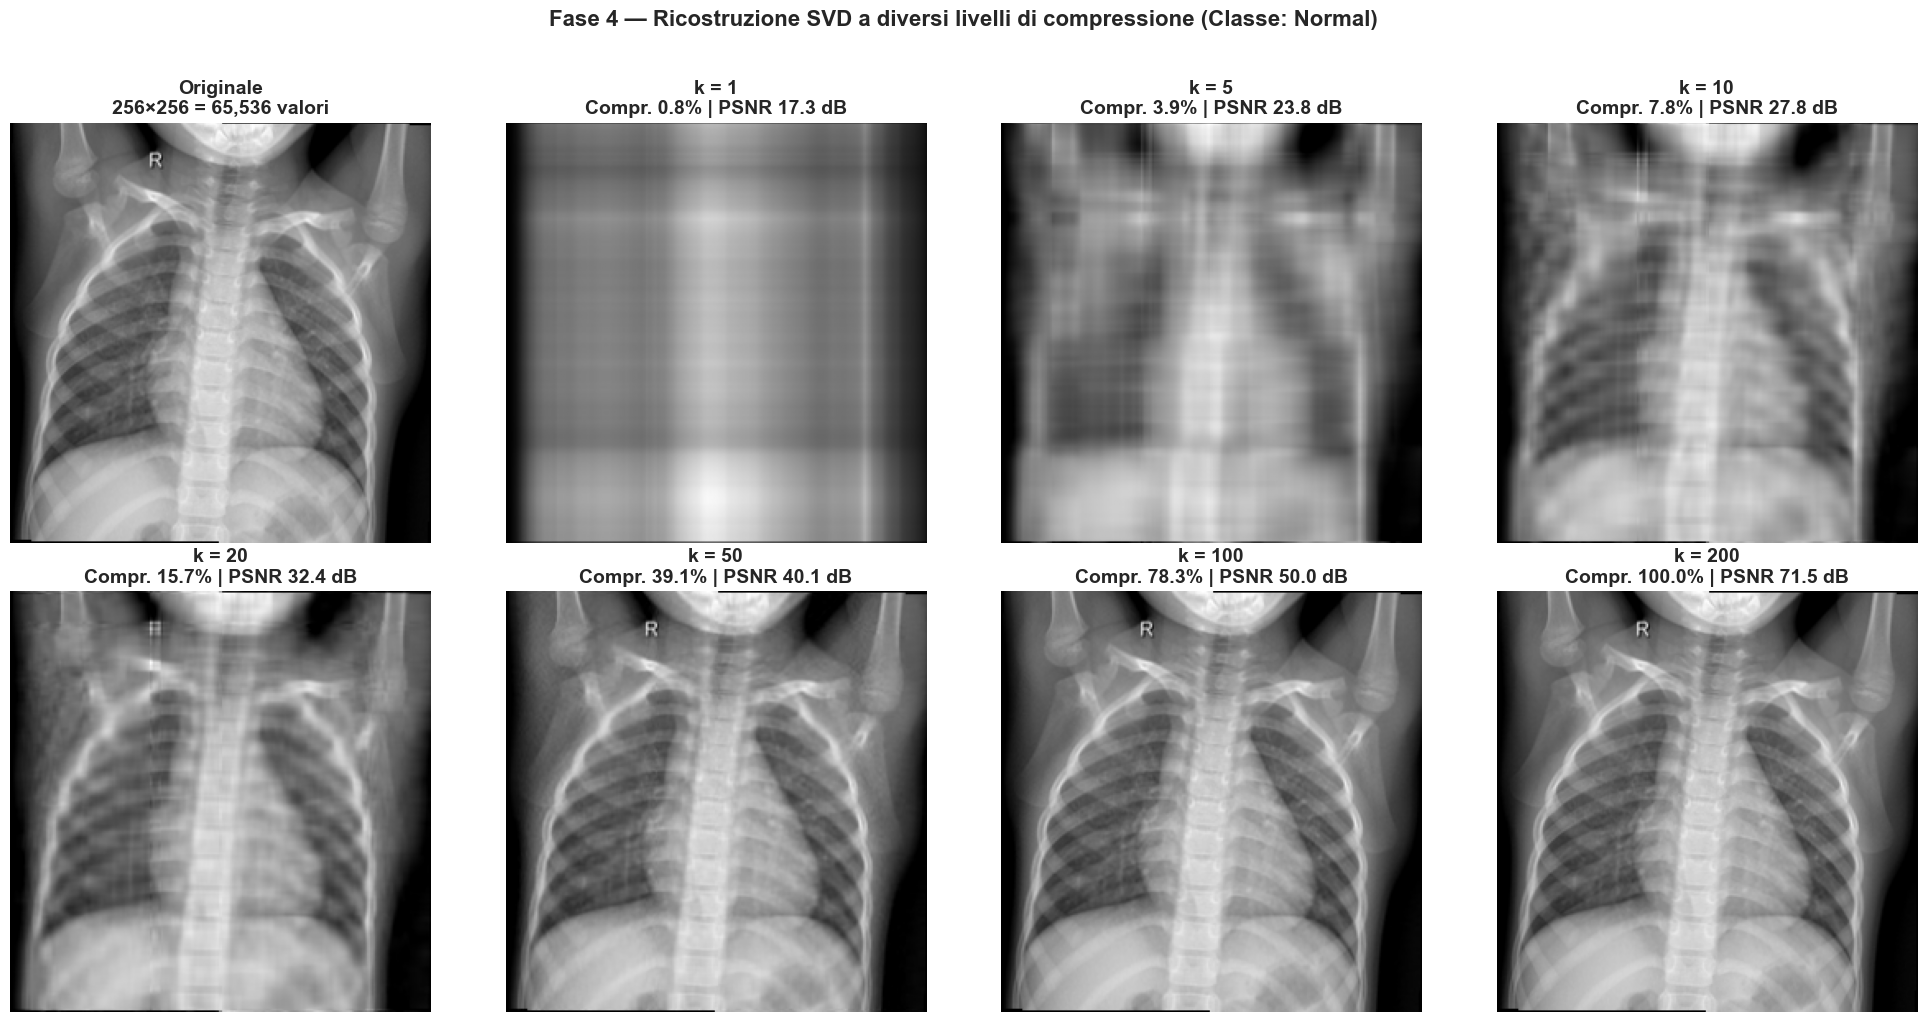

In [7]:
# === RICOSTRUZIONE CON DIVERSI k ===
plot_svd_reconstruction(demo_img, class_name="Normal")

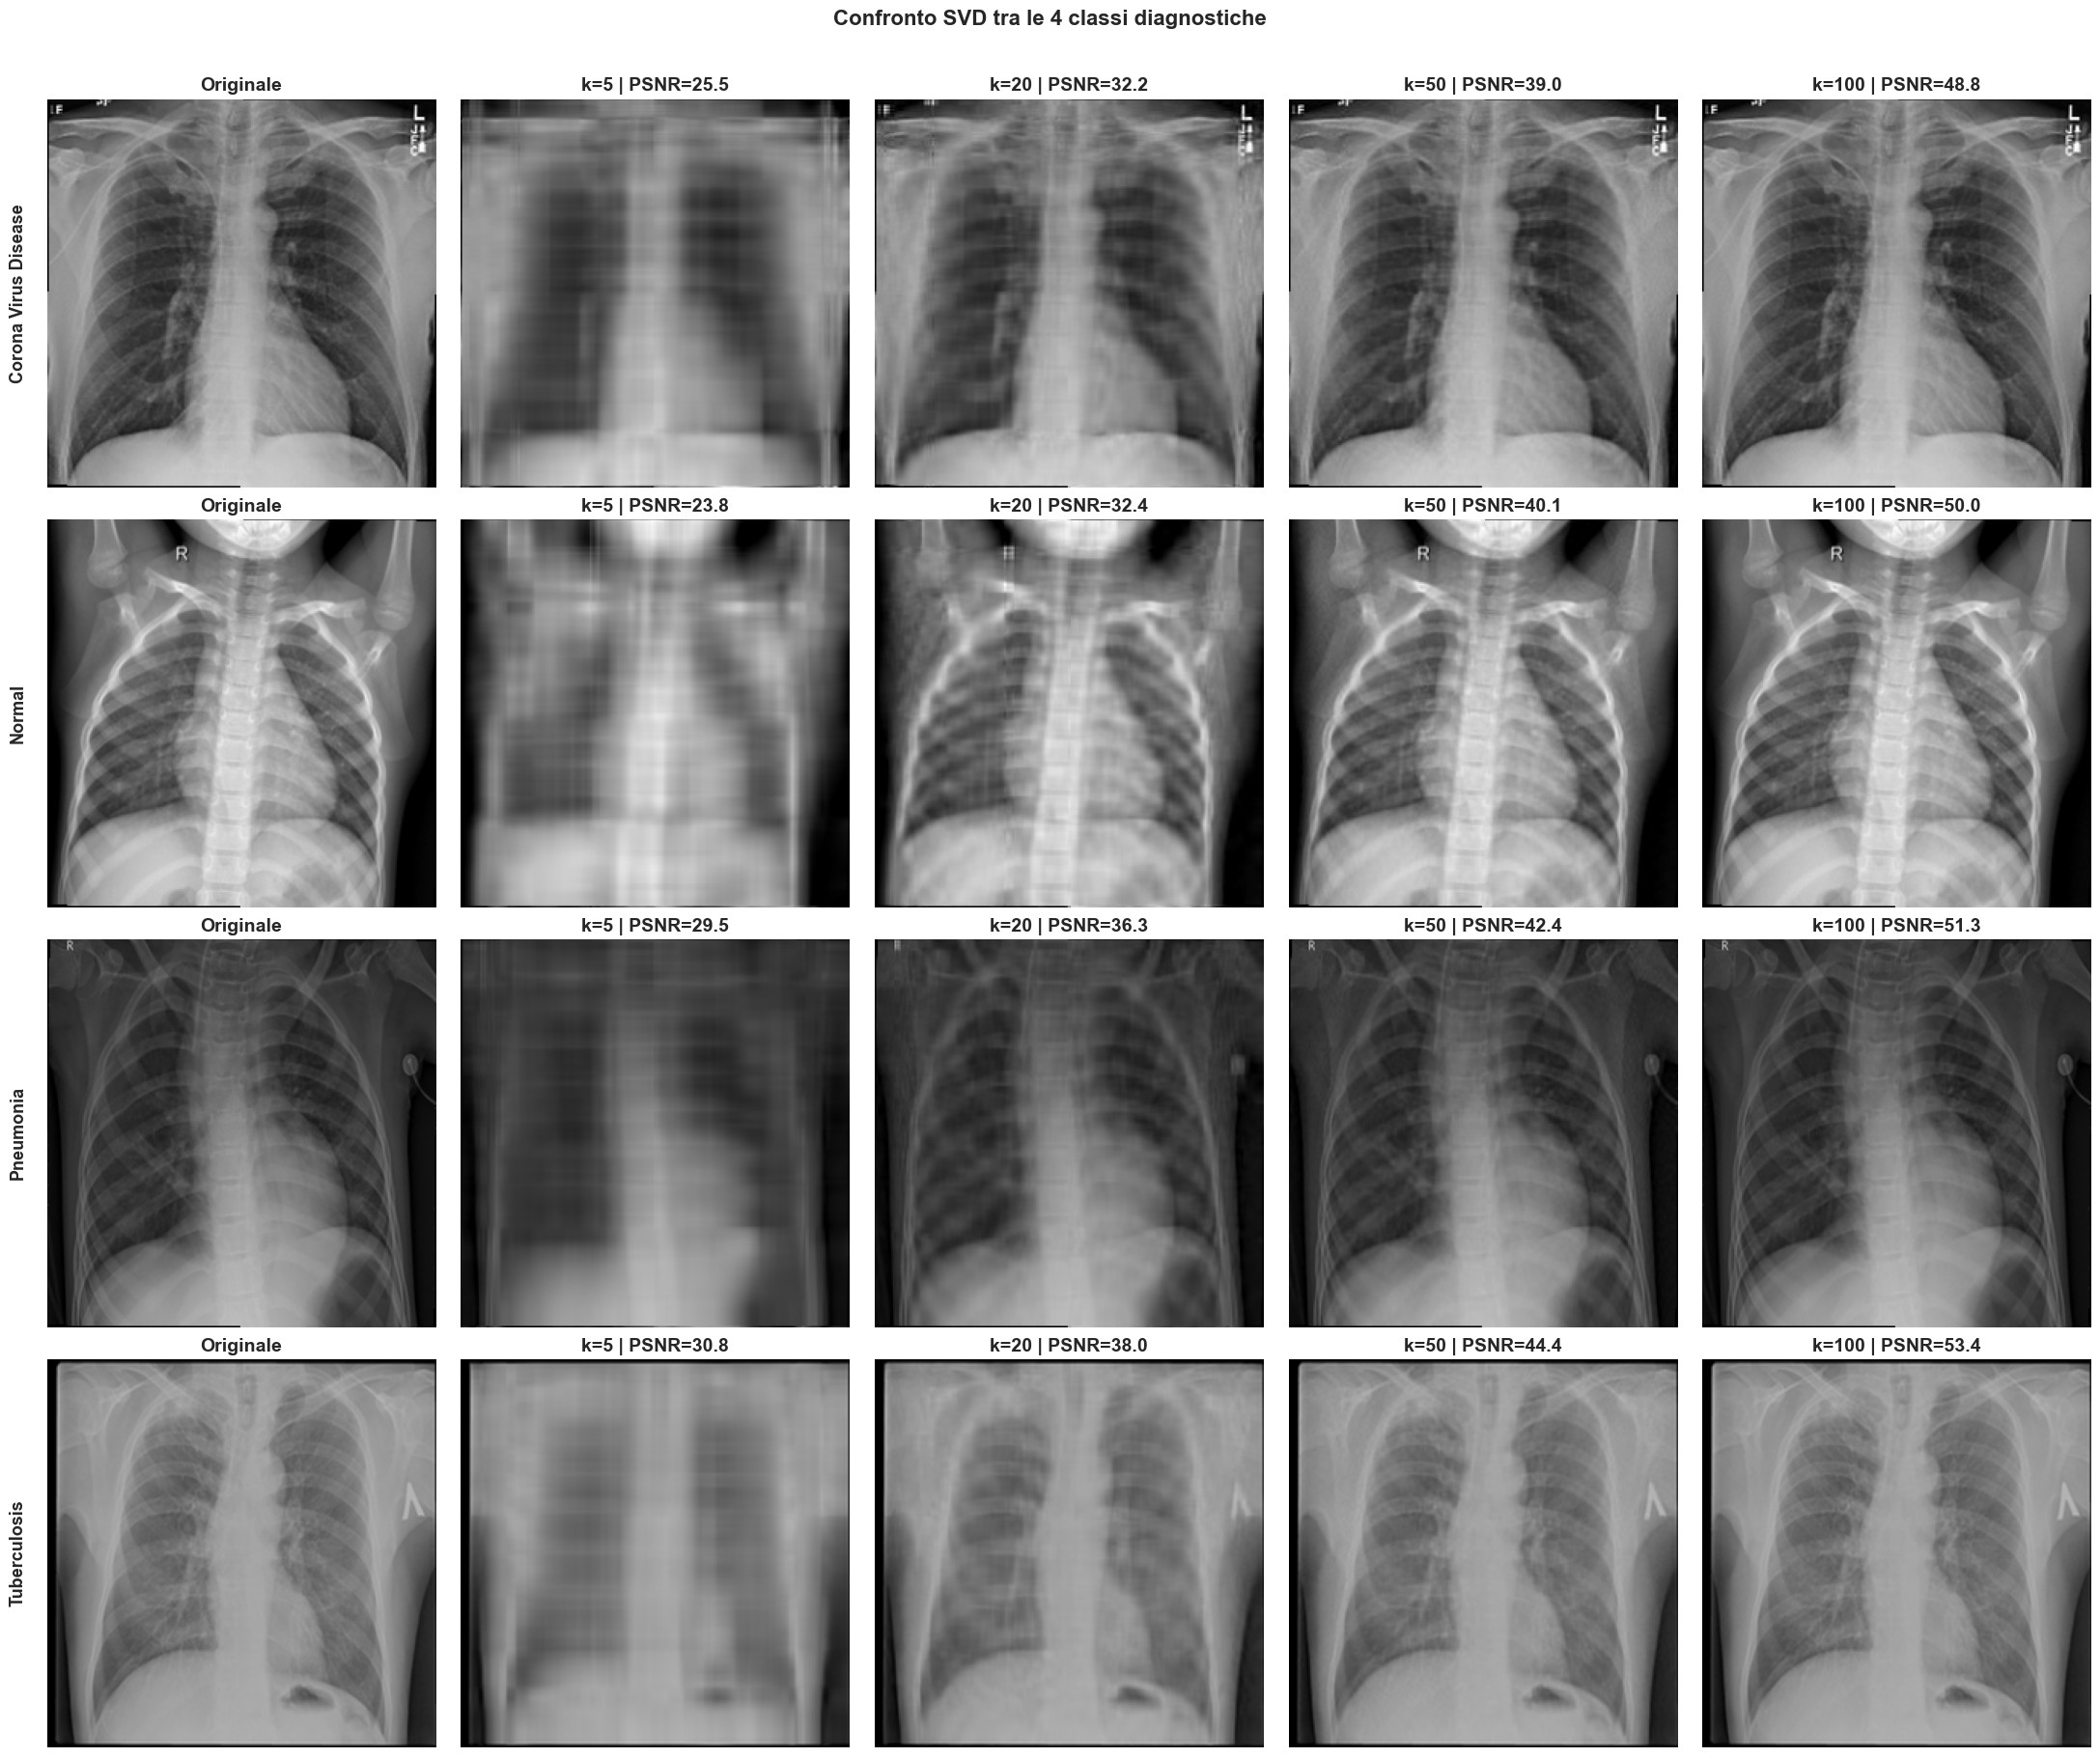

In [8]:
# === CONFRONTO TRA CLASSI ===
plot_class_comparison(images_by_class)

---
## Fase 5 -- Analisi Statistica e PCA

### 5.1 Varianza Spiegata dai Valori Singolari (Scree Plot)
La varianza spiegata dalla $i$-esima componente e' proporzionale a $\sigma_i^2$.
La **varianza cumulativa** ci dice quante componenti servono per catturare una certa
percentuale dell'informazione.

Corona Virus Disease          :  k(90%)=  1   k(95%)=  2   k(99%)=  7  su 256 totali
Normal                        :  k(90%)=  1   k(95%)=  2   k(99%)=  7  su 256 totali
Pneumonia                     :  k(90%)=  1   k(95%)=  1   k(99%)=  5  su 256 totali
Tuberculosis                  :  k(90%)=  1   k(95%)=  1   k(99%)=  2  su 256 totali


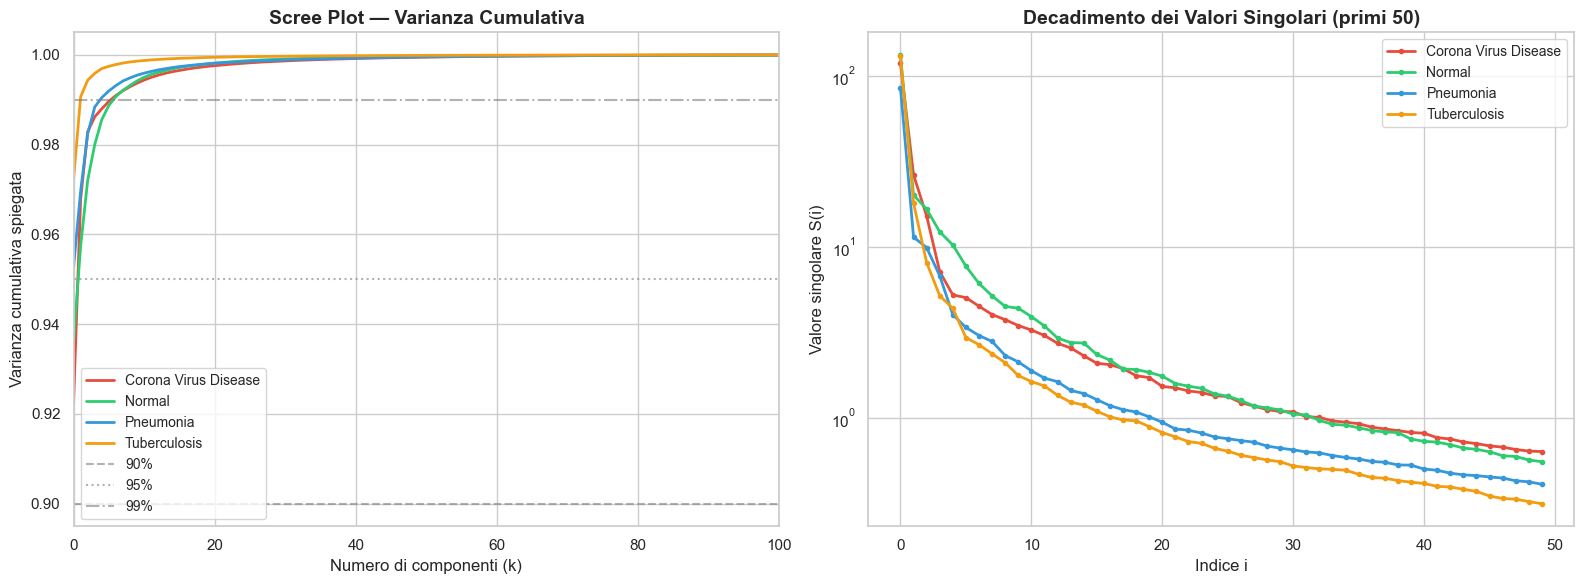

In [9]:
# === SCREE PLOT ===
plot_scree(images_by_class)

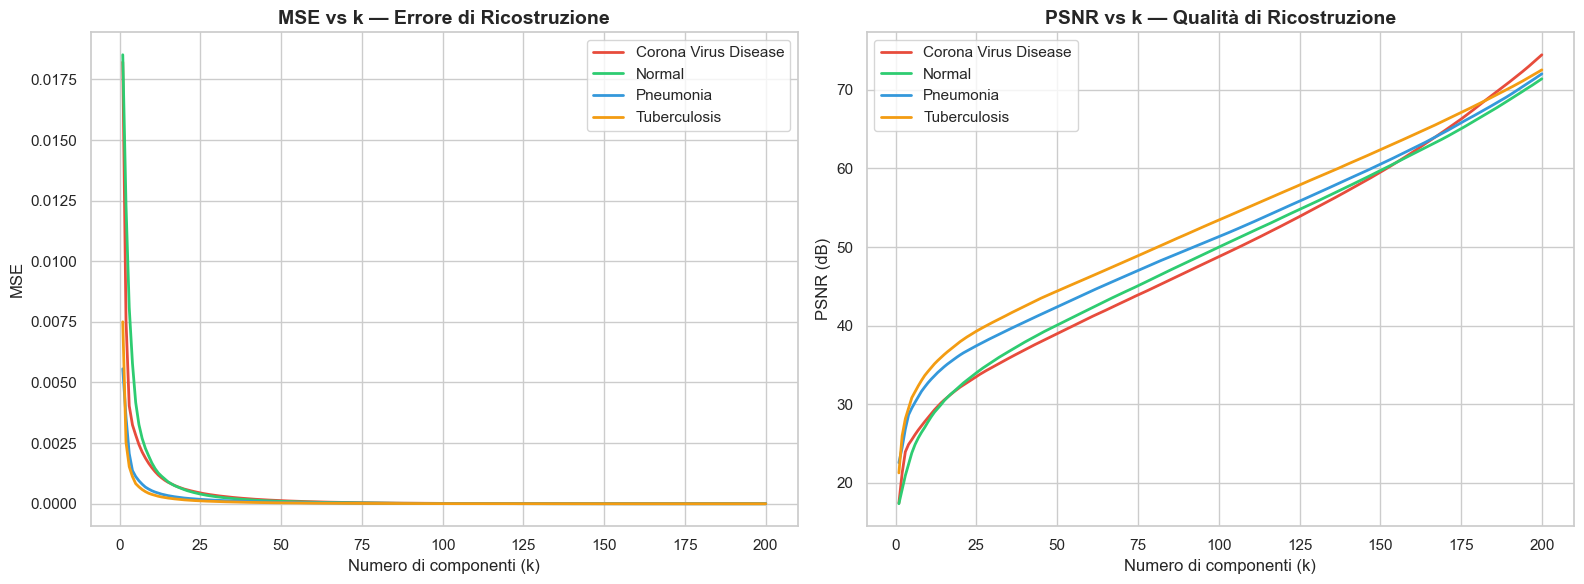

In [10]:
# === CURVA MSE e PSNR vs k ===
plot_mse_psnr(images_by_class)

### 5.2 PCA -- Riduzione Dimensionale sul Dataset

La PCA proietta le immagini (vettorizzate) in uno spazio a bassa dimensionalita'.
Questo ci permette di visualizzare la **separabilita'** tra le classi diagnostiche.

In [11]:
# === PCA SUL DATASET ===
pca_model, X_pca = run_pca(all_images)

Matrice dati X: (320, 65536)  (320 campioni, 65536 features)

Varianza spiegata dalle prime 50 componenti: 88.77%


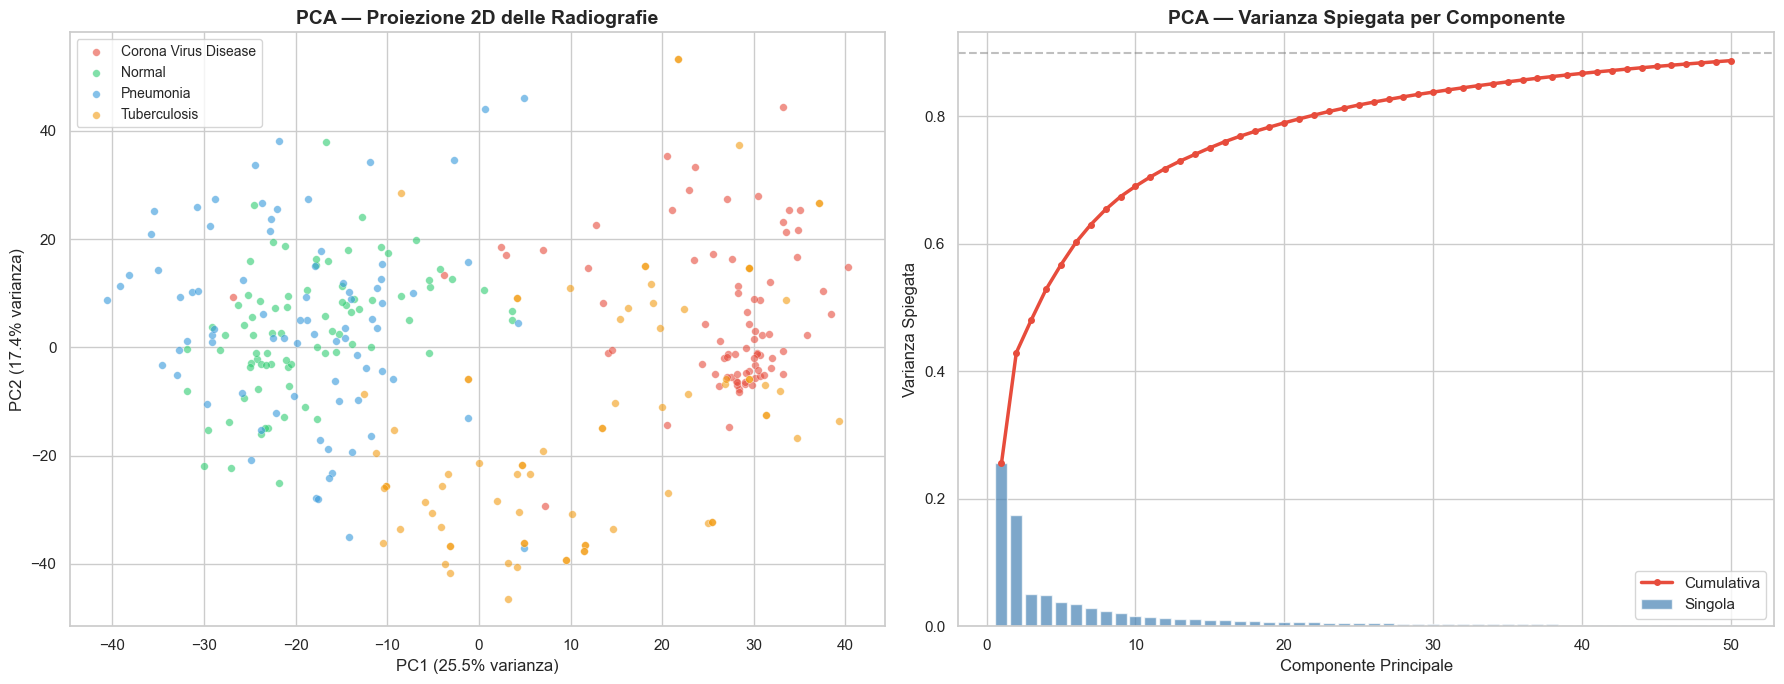

In [12]:
# === SCATTER PLOT PCA 2D ===
plot_pca_scatter(pca_model, X_pca, labels)

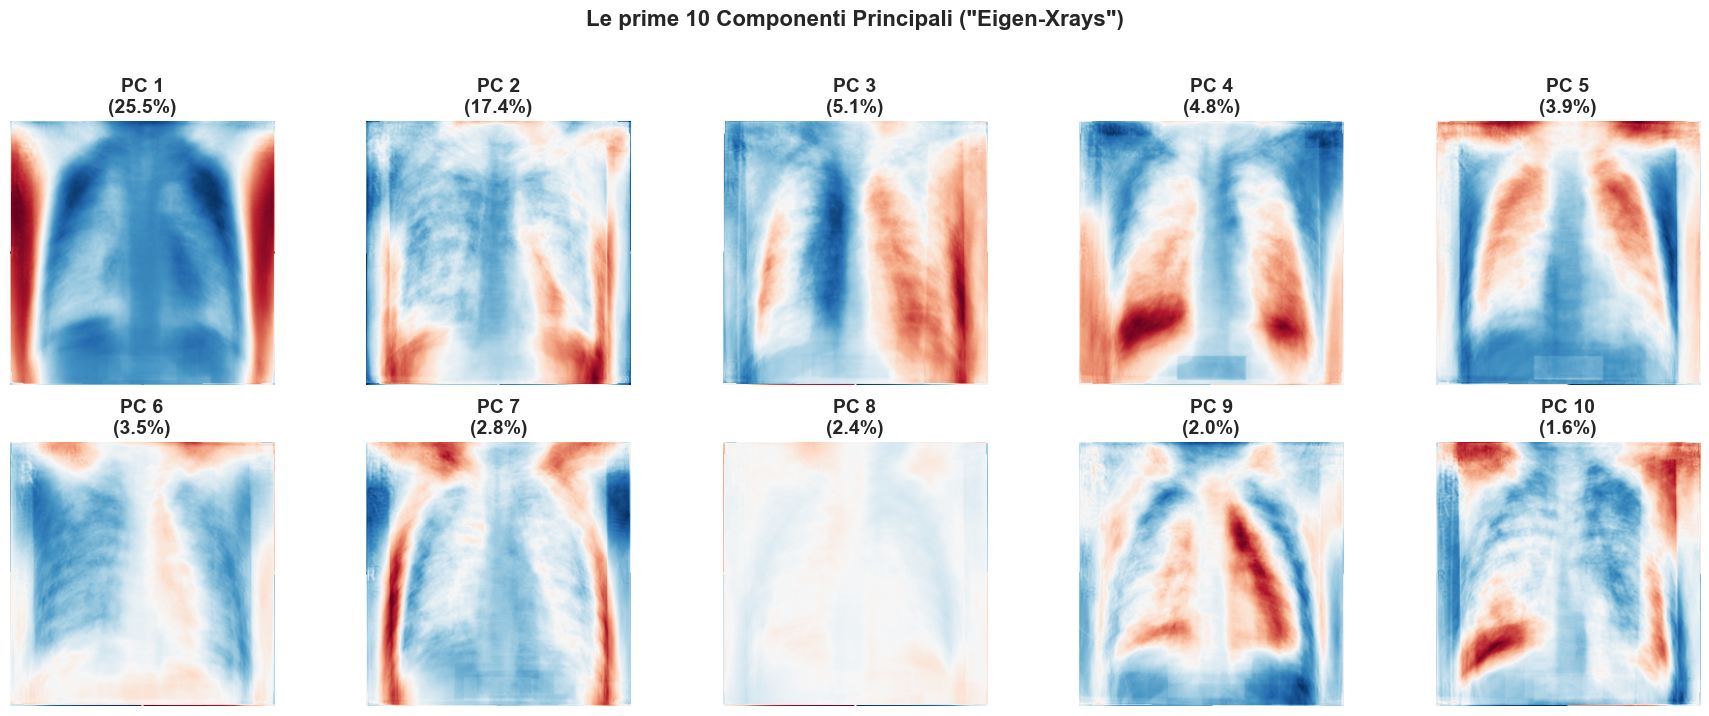

In [13]:
# === EIGENFACES (COMPONENTI PRINCIPALI COME IMMAGINI) ===
plot_eigenfaces(pca_model)

In [14]:
# === TABELLA RIASSUNTIVA ===
print_summary_table(demo_img, class_name="Normal")


TABELLA RIASSUNTIVA — TRADE-OFF COMPRESSIONE vs QUALITÀ  (Normal)

    k |  Rapporto Compr. |   Varianza |          MSE |  PSNR (dB)
-----------------------------------------------------------------
    1 |           0.78% |    93.60% |   0.01851605 |      17.32
    5 |           3.91% |    98.56% |   0.00414733 |      23.82
   10 |           7.83% |    99.42% |   0.00166610 |      27.78
   20 |          15.66% |    99.80% |   0.00057890 |      32.37
   50 |          39.14% |    99.97% |   0.00009788 |      40.09
  100 |          78.28% |   100.00% |   0.00000999 |      50.00
  150 |         100.00% |   100.00% |   0.00000105 |      59.77
  200 |         100.00% |   100.00% |   0.00000007 |      71.54
  256 |         100.00% |   100.00% |   0.00000000 |     301.51


---
## Conclusioni

1. **SVD come strumento di compressione**: Con sole 20-50 componenti singolari (su 256
   possibili), preserviamo oltre il 90% dell'informazione visiva. Il trade-off tra peso
   dati e qualita' e' chiaramente visibile nei grafici MSE/PSNR.

2. **Varianza Spiegata**: Lo scree plot mostra che le prime componenti catturano la
   maggior parte della varianza. Questo conferma che le immagini mediche hanno una forte
   struttura di basso rango sfruttabile per la compressione.

3. **PCA e Separabilita'**: La proiezione PCA 2D mostra come le diverse patologie
   occupino regioni (parzialmente) distinte nello spazio delle componenti principali,
   suggerendo che queste tecniche possono supportare anche la classificazione diagnostica.

4. **Eigenfaces (Eigen-Xrays)**: Le prime componenti principali rivelano i pattern
   strutturali dominanti nelle radiografie polmonari.